In [1]:
from google.colab import files

uploaded = files.upload()


Saving WhatsApp Image 2026-09-18 at 14.07.17.jpeg to WhatsApp Image 2026-09-18 at 14.07.17.jpeg


Dimensi gambar: (720, 1017, 3)


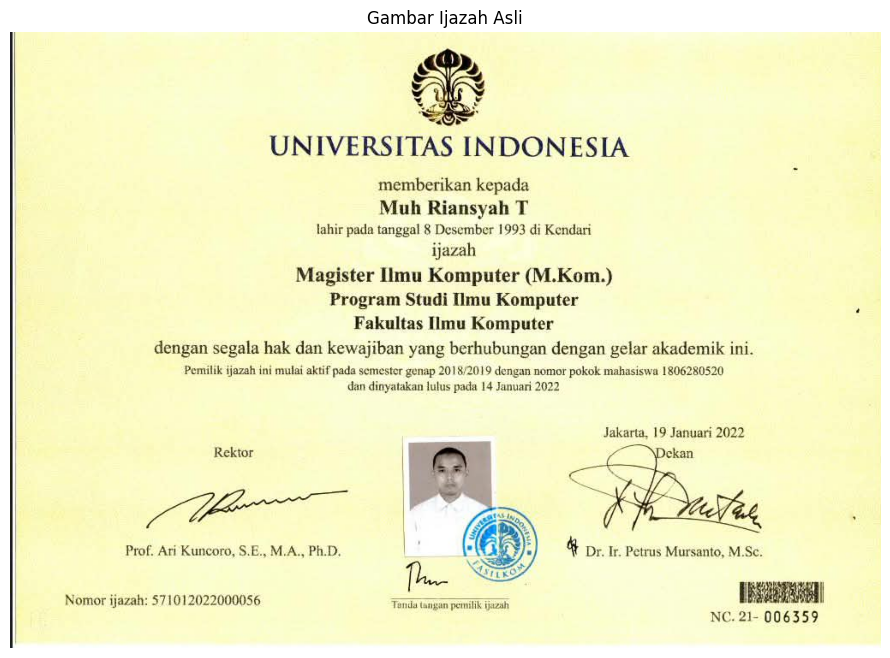

In [2]:
import cv2
import matplotlib.pyplot as plt

nama_file = next(iter(uploaded))

img = cv2.imread(nama_file)

if img is None:
    raise ValueError("Gambar tidak berhasil dibaca")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Dimensi gambar:", img.shape)

plt.figure(figsize=(14, 8))
plt.imshow(img_rgb)
plt.title("Gambar Ijazah Asli")
plt.axis("off")
plt.show()

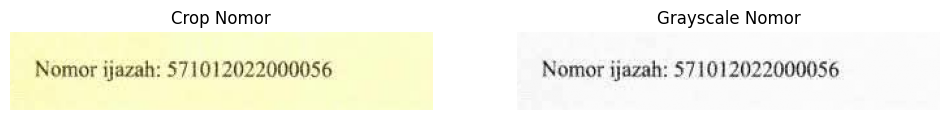

In [3]:
# Area nomor ijazah
x1, y1, x2, y2 = 45, 635, 370, 695

crop_nomor = img[y1:y2, x1:x2]
gray_nomor = cv2.cvtColor(crop_nomor, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(crop_nomor, cv2.COLOR_BGR2RGB))
plt.title("Crop Nomor")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_nomor, cmap="gray")
plt.title("Grayscale Nomor")
plt.axis("off")

plt.show()

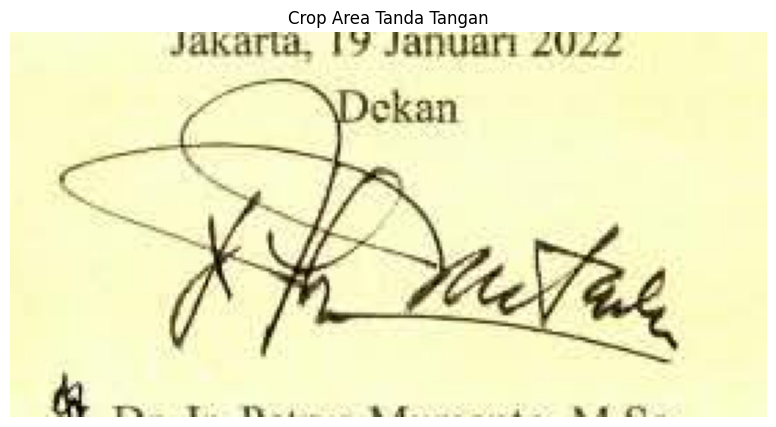

In [4]:
# Area tanda tangan di sebelah kanan
sx1, sy1, sx2, sy2 = 635, 465, 910, 605

crop_ttd = img[sy1:sy2, sx1:sx2]
gray_ttd = cv2.cvtColor(crop_ttd, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))
plt.imshow(cv2.cvtColor(crop_ttd, cv2.COLOR_BGR2RGB))
plt.title("Crop Area Tanda Tangan")
plt.axis("off")
plt.show()

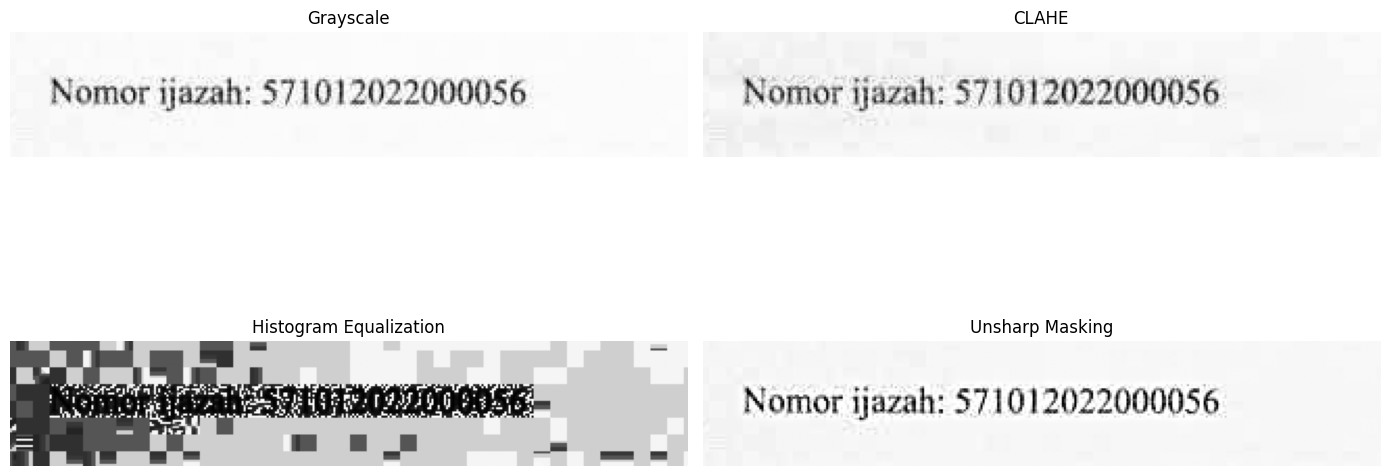

In [5]:
import cv2
import matplotlib.pyplot as plt

# Metode 1: CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
img_clahe = clahe.apply(gray_nomor)

# Metode 2: Histogram Equalization
img_hist = cv2.equalizeHist(gray_nomor)

# Metode 3: Unsharp Masking
blur = cv2.GaussianBlur(
    gray_nomor,
    (0, 0),
    2
)

img_unsharp = cv2.addWeighted(
    gray_nomor, 1.7,
    blur, -0.7,
    0
)

# Bandingkan hasil
hasil_enhancement = [
    ("Grayscale", gray_nomor),
    ("CLAHE", img_clahe),
    ("Histogram Equalization", img_hist),
    ("Unsharp Masking", img_unsharp)
]

plt.figure(figsize=(14, 8))

for i, (nama, gambar) in enumerate(hasil_enhancement, 1):
    plt.subplot(2, 2, i)
    plt.imshow(gambar, cmap="gray")
    plt.title(nama)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
!apt-get update -qq
!apt-get install -y tesseract-ocr
!pip install -q pytesseract jiwer

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.2 MB/s eta 0:00:00


In [7]:
import pytesseract

def baca_nomor(gambar):
    konfigurasi = (
        "--oem 3 --psm 7 "
        "-c tessedit_char_whitelist=0123456789"
    )

    teks = pytesseract.image_to_string(
        gambar,
        config=konfigurasi
    )

    return teks.strip()

In [8]:
hasil_ocr = {
    "Grayscale": baca_nomor(gray_nomor),
    "CLAHE": baca_nomor(img_clahe),
    "Histogram Equalization": baca_nomor(img_hist),
    "Unsharp Masking": baca_nomor(img_unsharp)
}

for metode, hasil in hasil_ocr.items():
    print(f"{metode}: {hasil}")

Grayscale: 571012022000056
CLAHE: 571012022000056
Histogram Equalization: 
Unsharp Masking: 571012022000056


In [9]:
from jiwer import cer
import pandas as pd

# Periksa dan koreksi berdasarkan dokumen sumber.
ground_truth = "571012022000056"

data = []

for metode, prediksi in hasil_ocr.items():
    nilai_cer = cer(ground_truth, prediksi)

    data.append({
        "Metode": metode,
        "Ground Truth": ground_truth,
        "Hasil OCR": prediksi,
        "CER (%)": round(nilai_cer * 100, 2)
    })

tabel_cer = pd.DataFrame(data)
tabel_cer = tabel_cer.sort_values("CER (%)")

display(tabel_cer)

,Metode,Ground Truth,Hasil OCR,CER (%)
0,Grayscale,571012022000056,571012022000056,0.0
1,CLAHE,571012022000056,571012022000056,0.0
3,Unsharp Masking,571012022000056,571012022000056,0.0
2,Histogram Equalization,571012022000056,,100.0


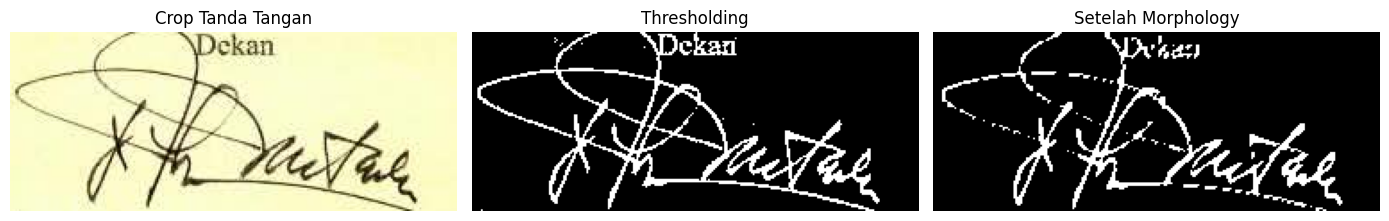

In [20]:

sx1, sy1, sx2, sy2 = 650, 485, 900, 585

crop_ttd_fokus = img[sy1:sy2, sx1:sx2]

gray_ttd_fokus = cv2.cvtColor(
    crop_ttd_fokus,
    cv2.COLOR_BGR2GRAY
)

threshold_fokus = cv2.adaptiveThreshold(
    gray_ttd_fokus,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    12
)

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2, 2)
)

opening_fokus = cv2.morphologyEx(
    threshold_fokus,
    cv2.MORPH_OPEN,
    kernel
)

closing_fokus = cv2.morphologyEx(
    opening_fokus,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(crop_ttd_fokus, cv2.COLOR_BGR2RGB))
plt.title("Crop Tanda Tangan")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(threshold_fokus, cmap="gray")
plt.title("Thresholding")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(closing_fokus, cmap="gray")
plt.title("Setelah Morphology")
plt.axis("off")

plt.tight_layout()
plt.show()

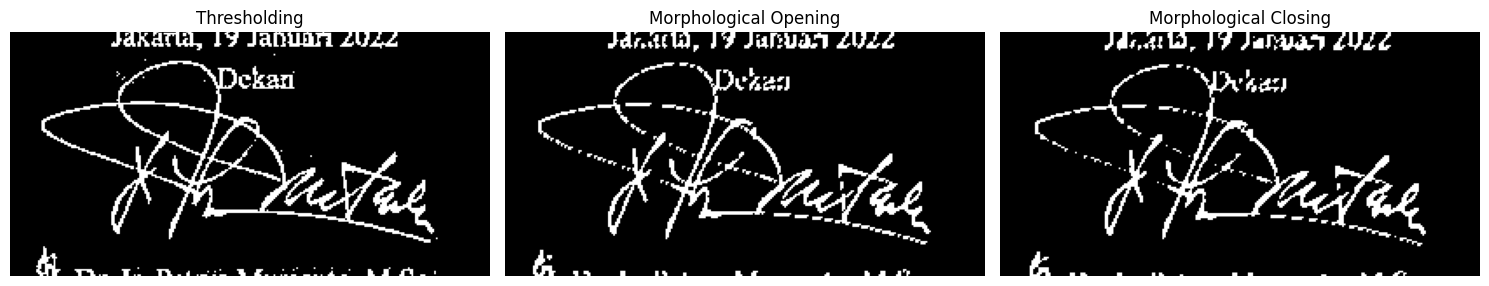

In [11]:
# Membuat kernel morfologi
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (2, 2)
)

# Mengurangi noise kecil
hasil_opening = cv2.morphologyEx(
    threshold_ttd,
    cv2.MORPH_OPEN,
    kernel
)

# Menutup celah kecil pada foreground
hasil_closing = cv2.morphologyEx(
    hasil_opening,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(threshold_ttd, cmap="gray")
plt.title("Thresholding")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(hasil_opening, cmap="gray")
plt.title("Morphological Opening")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(hasil_closing, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
import numpy as np

# Rasio piksel foreground (putih)
rasio_tinta = (
    np.count_nonzero(hasil_closing)
    / hasil_closing.size
)

# Hitung komponen terhubung
jumlah_label, label_image, statistik, pusat = (
    cv2.connectedComponentsWithStats(
        hasil_closing,
        connectivity=8
    )
)

# Abaikan komponen yang terlalu kecil
luas_komponen = statistik[1:, cv2.CC_STAT_AREA]
jumlah_komponen = int(
    np.sum(luas_komponen >= 4)
)

print("Rasio tinta:", round(rasio_tinta, 4))
print("Jumlah komponen:", jumlah_komponen)

Rasio tinta: 0.0865
Jumlah komponen: 63


In [13]:
if (
    0.002 <= rasio_tinta <= 0.35
    and jumlah_komponen >= 3
):
    status_ttd = "PRESENT"
else:
    status_ttd = "NOT PRESENT"

print("Tanda Tangan:", status_ttd)

Tanda Tangan: PRESENT


In [14]:
metode_terbaik = tabel_cer.iloc[0]["Metode"]
nomor_terbaca = hasil_ocr[metode_terbaik]
cer_terbaik = tabel_cer.iloc[0]["CER (%)"]

print("=" * 40)
print("HASIL VERIFIKASI IJAZAH")
print("=" * 40)
print("Nomor Ijazah :", nomor_terbaca)
print("Tanda Tangan :", status_ttd)
print("Metode OCR   :", metode_terbaik)
print("CER          :", f"{cer_terbaik:.2f}%")

HASIL VERIFIKASI IJAZAH
Nomor Ijazah : 571012022000056
Tanda Tangan : PRESENT
Metode OCR   : Grayscale
CER          : 0.00%


In [15]:
tabel_cer.to_csv(
    "hasil_evaluasi_cer.csv",
    index=False
)

from google.colab import files
files.download("hasil_evaluasi_cer.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>